# GNN Pre-Training
Self-supervised pre-training of the GNN encoder using:
- **Contrastive loss** (SimCLR / NT-Xent) on augmented graph pairs
- **Node reconstruction loss** (autoencoder-style MSE)

Saves the best checkpoint to `results/gnn_pretrained.pt`.

In [1]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

CUDA available: True
Device: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import yaml
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.data import Data, Batch
from torch_geometric.nn import global_mean_pool
import matplotlib.pyplot as plt

from models.encoder import GraphEncoder
from utils.graph_builder import build_network_graph

c:\Users\nirmi\Desktop\LABS\PF LAB\6g-gnn-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
CONFIG_PATH = os.path.join(PROJECT_ROOT, "configs", "config.yaml")
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Config:", config)

Using device: cuda
Config: {'network': {'num_base_stations': 12, 'num_users': 40, 'area_size': 3000, 'frequency_ghz': 28, 'max_bandwidth_mhz': 400, 'max_edge_distance': 900}, 'gnn': {'in_channels': 5, 'hidden_channels': 128, 'out_channels': 64, 'num_layers': 4, 'dropout': 0.2, 'pretrain_epochs': 100, 'pretrain_lr': 0.0005, 'pretrain_batch': 32, 'num_pretrain_graphs': 500}, 'training': {'episodes': 800, 'lr': 0.0003, 'gamma': 0.99, 'batch_size': 128, 'memory_size': 50000, 'target_update_freq': 5, 'epsilon_start': 1.0, 'epsilon_min': 0.02, 'epsilon_decay': 0.997, 'hidden_dim': 512, 'tau': 0.005}}


## 1. Generate Synthetic Dataset

In [4]:
def random_graph(config):
    net = config["network"]
    num_bs   = net["num_base_stations"]
    num_users = net["num_users"]
    area     = net["area_size"]
    max_dist = net.get("max_edge_distance", area * 0.3)

    bs_pos   = np.random.uniform(0, area, (num_bs, 2)).astype(np.float32)
    user_pos = np.random.uniform(0, area, (num_users, 2)).astype(np.float32)
    alloc    = np.random.randint(0, num_bs, num_users)
    return build_network_graph(bs_pos, user_pos, alloc, max_dist, area)

gnn_cfg   = config.get("gnn", {})
NUM_GRAPHS = gnn_cfg.get("num_pretrain_graphs", 500)

print(f"Generating {NUM_GRAPHS} random graphs...")
graphs = [random_graph(config) for _ in range(NUM_GRAPHS)]
print(f"Done. Example node feature shape: {graphs[0].x.shape}")

Generating 500 random graphs...
Done. Example node feature shape: torch.Size([52, 5])


## 2. Augmentation & Loss Helpers

In [5]:
def augment_graph(data, noise_std=0.02, drop_edge_p=0.1):
    """Add node-feature noise + randomly drop edges."""
    x = (data.x + torch.randn_like(data.x) * noise_std).clamp(0, 1)
    if data.edge_index.size(1) > 0 and drop_edge_p > 0:
        mask = torch.rand(data.edge_index.size(1)) > drop_edge_p
        edge_index = data.edge_index[:, mask]
        edge_attr  = data.edge_attr[mask] if data.edge_attr is not None else None
    else:
        edge_index = data.edge_index
        edge_attr  = data.edge_attr
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim), nn.GELU(),
            nn.Linear(in_dim, proj_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


def contrastive_loss(z1, z2, temperature=0.1):
    """NT-Xent loss for paired graph embeddings."""
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)          # (2B, D)
    sim = torch.mm(z, z.T) / temperature    # (2B, 2B)
    mask = torch.eye(2 * B, device=z.device).bool()
    sim.masked_fill_(mask, float("-inf"))
    labels = torch.cat([
        torch.arange(B, 2 * B),
        torch.arange(0, B),
    ]).to(z.device)
    return F.cross_entropy(sim, labels)

print("Helpers defined.")

Helpers defined.


## 3. Build Model

In [6]:
IN_CH     = gnn_cfg.get("in_channels", 5)
HIDDEN    = gnn_cfg.get("hidden_channels", 128)
OUT_CH    = gnn_cfg.get("out_channels", 64)
N_LAYERS  = gnn_cfg.get("num_layers", 4)
DROPOUT   = gnn_cfg.get("dropout", 0.2)

encoder   = GraphEncoder(IN_CH, HIDDEN, OUT_CH, N_LAYERS, DROPOUT).to(device)
proj_head = ProjectionHead(OUT_CH, proj_dim=64).to(device)
decoder   = nn.Sequential(
    nn.Linear(OUT_CH, HIDDEN), nn.GELU(),
    nn.Linear(HIDDEN, IN_CH),
).to(device)

print(encoder)

GraphEncoder(
  (gnn): GNNModel(
    (input_proj): Sequential(
      (0): Linear(in_features=5, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
    )
    (blocks): ModuleList(
      (0-2): 3 x ResGATBlock(
        (conv): GATv2Conv(128, 32, heads=4)
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (proj): Identity()
      )
    )
    (out_block): ResGATBlock(
      (conv): GATv2Conv(128, 16, heads=4)
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (proj): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (graph_proj): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
  )
)


## 4. Training Loop

In [7]:
EPOCHS     = gnn_cfg.get("pretrain_epochs", 100)
LR         = gnn_cfg.get("pretrain_lr", 0.0005)
BATCH_SIZE = gnn_cfg.get("pretrain_batch", 32)

params    = list(encoder.parameters()) + list(proj_head.parameters()) + list(decoder.parameters())
optimizer = AdamW(params, lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

best_loss   = float("inf")
epoch_losses = []

for epoch in range(1, EPOCHS + 1):
    encoder.train(); proj_head.train(); decoder.train()
    indices    = np.random.permutation(NUM_GRAPHS)
    total_loss = 0.0
    n_batches  = 0

    for start in range(0, NUM_GRAPHS - BATCH_SIZE + 1, BATCH_SIZE):
        batch_graphs = [graphs[i] for i in indices[start: start + BATCH_SIZE]]

        aug1 = Batch.from_data_list([augment_graph(g) for g in batch_graphs]).to(device)
        aug2 = Batch.from_data_list([augment_graph(g) for g in batch_graphs]).to(device)

        _, node_emb1 = encoder(aug1)
        _, node_emb2 = encoder(aug2)

        g_emb1 = proj_head(global_mean_pool(node_emb1, aug1.batch))
        g_emb2 = proj_head(global_mean_pool(node_emb2, aug2.batch))
        loss_contrast = contrastive_loss(g_emb1, g_emb2)

        orig_batch = Batch.from_data_list(batch_graphs).to(device)
        _, node_emb_orig = encoder(orig_batch)
        recon = decoder(node_emb_orig)
        loss_recon = F.mse_loss(recon, orig_batch.x)

        loss = loss_contrast + loss_recon
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(params, 5.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    scheduler.step()
    avg_loss = total_loss / max(n_batches, 1)
    epoch_losses.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(encoder.gnn.state_dict(), os.path.join(RESULTS_DIR, "gnn_pretrained.pt"))

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | loss={avg_loss:.4f} | best={best_loss:.4f}")

print(f"\nPre-training done. Best loss={best_loss:.4f}")
print(f"Saved → {RESULTS_DIR}/gnn_pretrained.pt")

Epoch   1/100 | loss=3.9484 | best=3.9484
Epoch  10/100 | loss=0.3779 | best=0.3779
Epoch  20/100 | loss=0.2139 | best=0.2139
Epoch  30/100 | loss=0.1539 | best=0.1539
Epoch  40/100 | loss=0.1459 | best=0.1336
Epoch  50/100 | loss=0.1330 | best=0.1269
Epoch  60/100 | loss=0.1092 | best=0.1092
Epoch  70/100 | loss=0.1040 | best=0.1017
Epoch  80/100 | loss=0.0949 | best=0.0949
Epoch  90/100 | loss=0.0915 | best=0.0915
Epoch 100/100 | loss=0.0903 | best=0.0881

Pre-training done. Best loss=0.0881
Saved → c:\Users\nirmi\Desktop\LABS\PF LAB\6g-gnn-project\results/gnn_pretrained.pt


## 5. Loss Curve

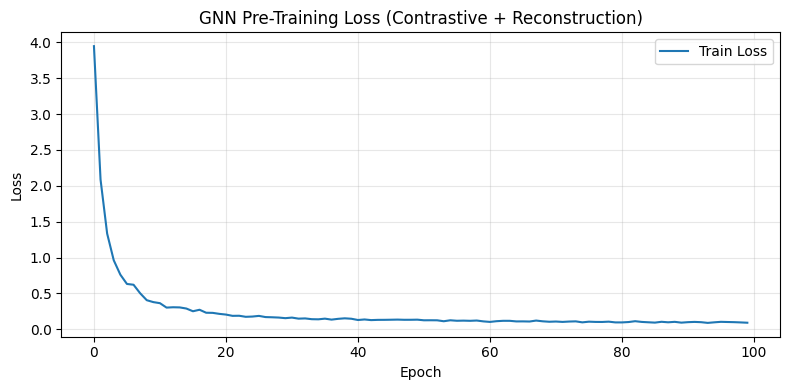

Plot saved.


In [8]:
plt.figure(figsize=(8, 4))
plt.plot(epoch_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN Pre-Training Loss (Contrastive + Reconstruction)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "plots", "gnn_pretrain_loss.png"), dpi=150)
plt.show()
print("Plot saved.")